Full dataset : 2,062,185 rows
Working subset: 10,000 rows


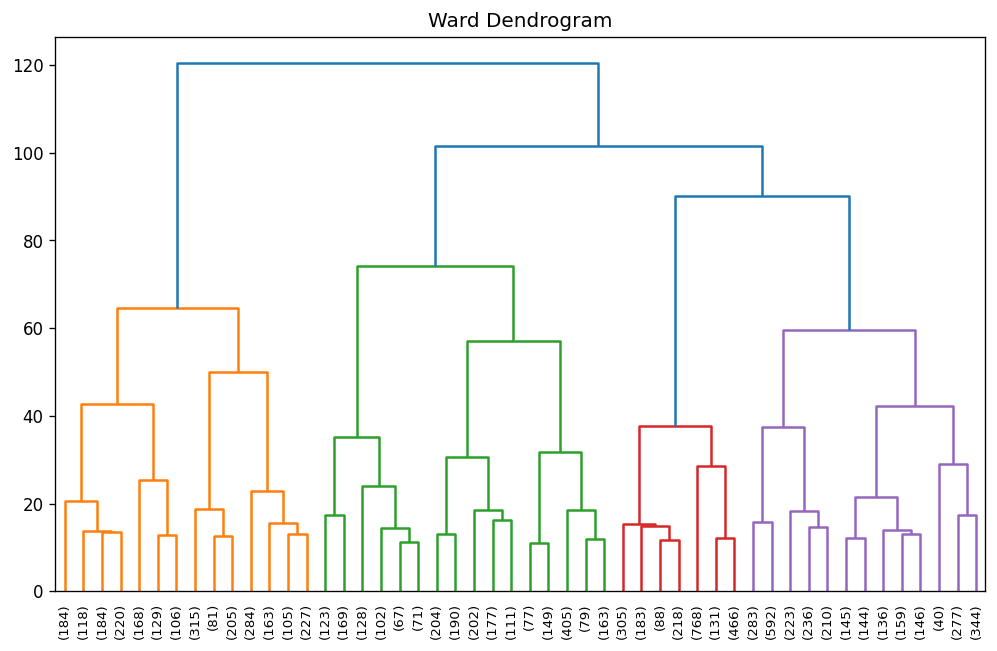

In [1]:
# Imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
from scipy.cluster import hierarchy
from scipy.cluster.hierarchy import fcluster
from sklearn.preprocessing import StandardScaler
from sklearn.metrics.pairwise import haversine_distances
from sklearn.metrics import silhouette_score, davies_bouldin_score

# -----------------------
# Load Data
# -----------------------
warnings.filterwarnings("ignore", category=FutureWarning)
plt.rcParams["figure.dpi"] = 120
RANDOM_STATE = 42
DATA_PATH = "../Data/raw/merged_trip_emissions_coordinates.csv"
SUBSET_N = 10000


# Sample for speed
df_full = pd.read_csv(DATA_PATH, low_memory=False)
df = df_full.sample(n=min(SUBSET_N, len(df_full)), random_state=RANDOM_STATE).reset_index(drop=True)

# -----------------------
# Preprocessing
# -----------------------
df["pickup_datetime"] = pd.to_datetime(df["pickup_datetime"], errors="coerce")
df["pickup_lat"] = pd.to_numeric(df["pickup_lat"], errors="coerce")
df["pickup_lon"] = pd.to_numeric(df["pickup_lon"], errors="coerce")
df["trip_miles"] = pd.to_numeric(df["trip_miles"], errors="coerce")
df["co2_total_g"] = pd.to_numeric(df["co2_total_g"], errors="coerce")
df["trip_time"] = pd.to_numeric(df["trip_time"], errors="coerce")

df = df.dropna(subset=["pickup_lat", "pickup_lon", "pickup_datetime", "PULocationID"])
print(f"Full dataset : {len(df_full):,} rows")
print(f"Working subset: {len(df):,} rows")

# Time features
df["pickup_hour"] = df["pickup_datetime"].dt.hour
df["hour_sin"] = np.sin(2 * np.pi * df["pickup_hour"] / 24)
df["hour_cos"] = np.cos(2 * np.pi * df["pickup_hour"] / 24)

# -----------------------
# Feature Scaling
# -----------------------
features = ["pickup_lat", "pickup_lon", "hour_sin", "hour_cos"]

scaler = StandardScaler()
X = scaler.fit_transform(df[features])

# -----------------------
# Clustering (Ward)
# -----------------------
clus = hierarchy.linkage(X, method="ward")

plt.figure(figsize=(10, 6))
hierarchy.dendrogram(clus, truncate_mode="lastp", p=50)
plt.title("Ward Dendrogram")
plt.show()


Max linkage distance : 120.42
Min linkage distance : 0.0000
75th percentile      : 0.29
90th percentile      : [0.86278746 0.86303582 0.86484046 0.86685047 0.86707462]

Top 20 merge distances:
[120.42 101.48  90.12  74.06  64.5   59.6   57.18  50.    42.71  42.3
  37.78  37.55  35.19  31.76  30.5   29.03  28.57  25.39  23.97  22.85]


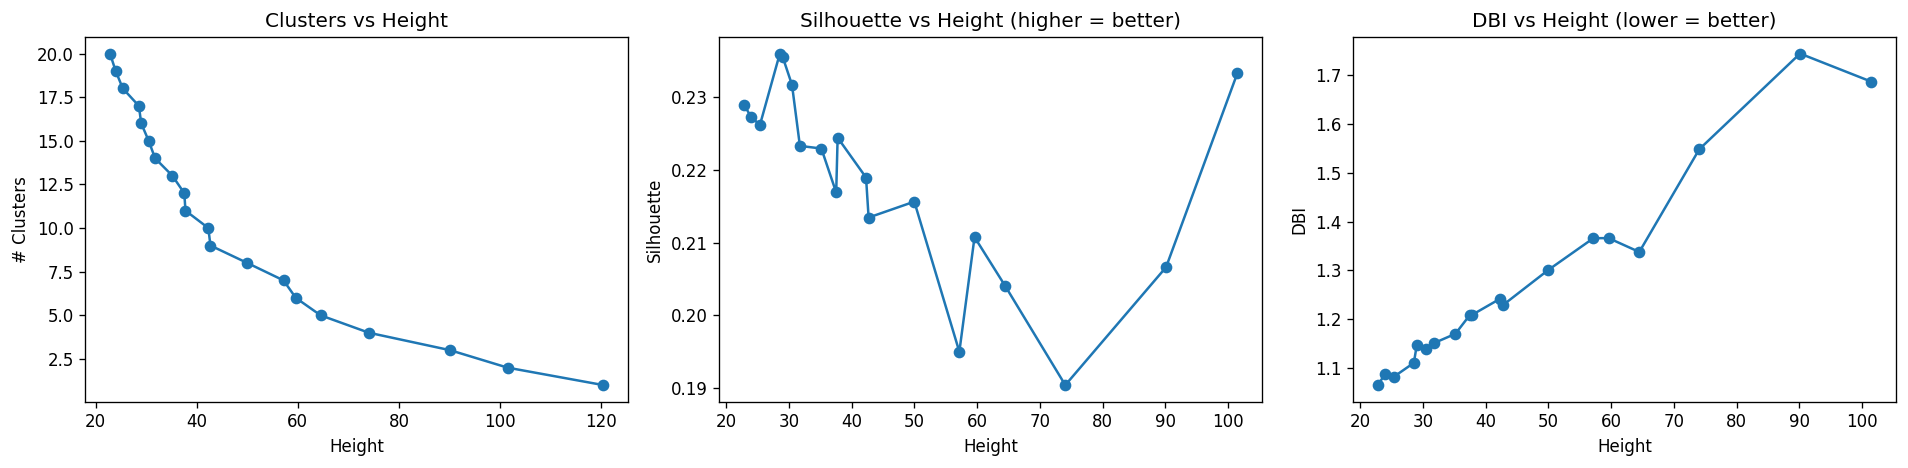

Best height = 28.565
Clusters at best height = 17
Best silhouette = 0.2359


count      17.000000
mean      588.235294
std       301.996591
min        40.000000
25%       394.000000
50%       621.000000
75%       730.000000
max      1365.000000
Name: count, dtype: float64

In [2]:
# Find optimal cut height

print(f"Max linkage distance : {clus[:, 2].max():.2f}")
print(f"Min linkage distance : {clus[:, 2].min():.4f}")
print(f"75th percentile      : {np.percentile(clus[:, 2], 75):.2f}")
print(f"90th percentile      : {clus[:, 2][int(len(clus)*0.90):][:5]}")

# Look at the last 20 merge distances (these are the meaningful ones)
print("\nTop 20 merge distances:")
print(np.sort(clus[:, 2])[-20:][::-1].round(2))


heights = np.sort(clus[:, 2])[-20:]  # top 20 largest merges
#heights = np.linspace(0, clus[:,2].max(), 50)  # 50 candidate heights
silhouettes = []
dbi_scores  = []
num_clusters = []

for h in heights:
    labels = fcluster(clus, t=h, criterion='distance')
    
    k = len(set(labels))
    num_clusters.append(k)
    
    # skip invalid cases
    if k <= 1 or k >= len(X):
        silhouettes.append(np.nan)
        dbi_scores.append(np.nan)
        continue
    
    silhouettes.append(
        silhouette_score(X, labels, sample_size=min(5000, len(X)))
    )
    dbi_scores.append(
        davies_bouldin_score(X, labels)
    )

# Plot results
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

axes[0].plot(heights, num_clusters, marker="o")
axes[0].set_title("Clusters vs Height")
axes[0].set_xlabel("Height"); axes[0].set_ylabel("# Clusters")

axes[1].plot(heights, silhouettes, marker="o")
axes[1].set_title("Silhouette vs Height (higher = better)")
axes[1].set_xlabel("Height"); axes[1].set_ylabel("Silhouette")
axes[2].plot(heights, dbi_scores, marker="o")
axes[2].set_title("DBI vs Height (lower = better)")
axes[2].set_xlabel("Height"); axes[2].set_ylabel("DBI")

plt.tight_layout()
plt.show()

# Best height based on silhouette
best_idx = np.nanargmax(silhouettes)
BEST_HEIGHT = heights[best_idx]
best_labels = fcluster(clus, t=BEST_HEIGHT, criterion='distance')

df["hier_cluster"] = best_labels

print(f"Best height = {BEST_HEIGHT:.3f}")
print(f"Clusters at best height = {num_clusters[best_idx]}")
print(f"Best silhouette = {silhouettes[best_idx]:.4f}")

pd.Series(best_labels).value_counts().describe()

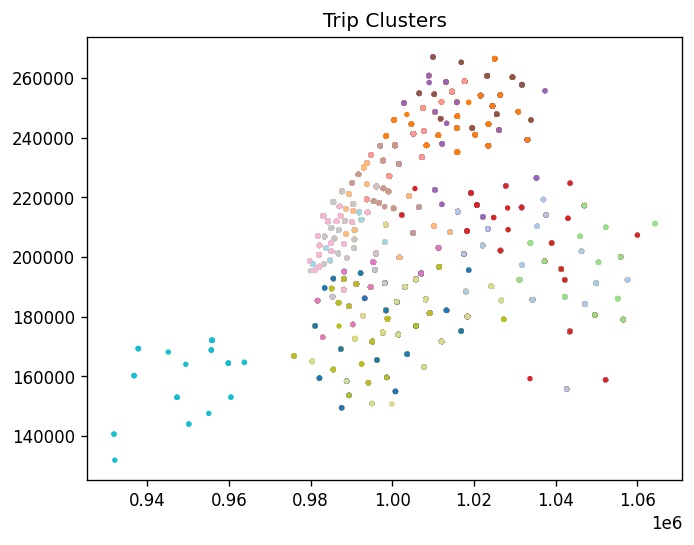

In [3]:
plt.scatter(df["pickup_lon"], df["pickup_lat"], c=best_labels, s=5, cmap="tab20")
plt.title("Trip Clusters")
plt.show()

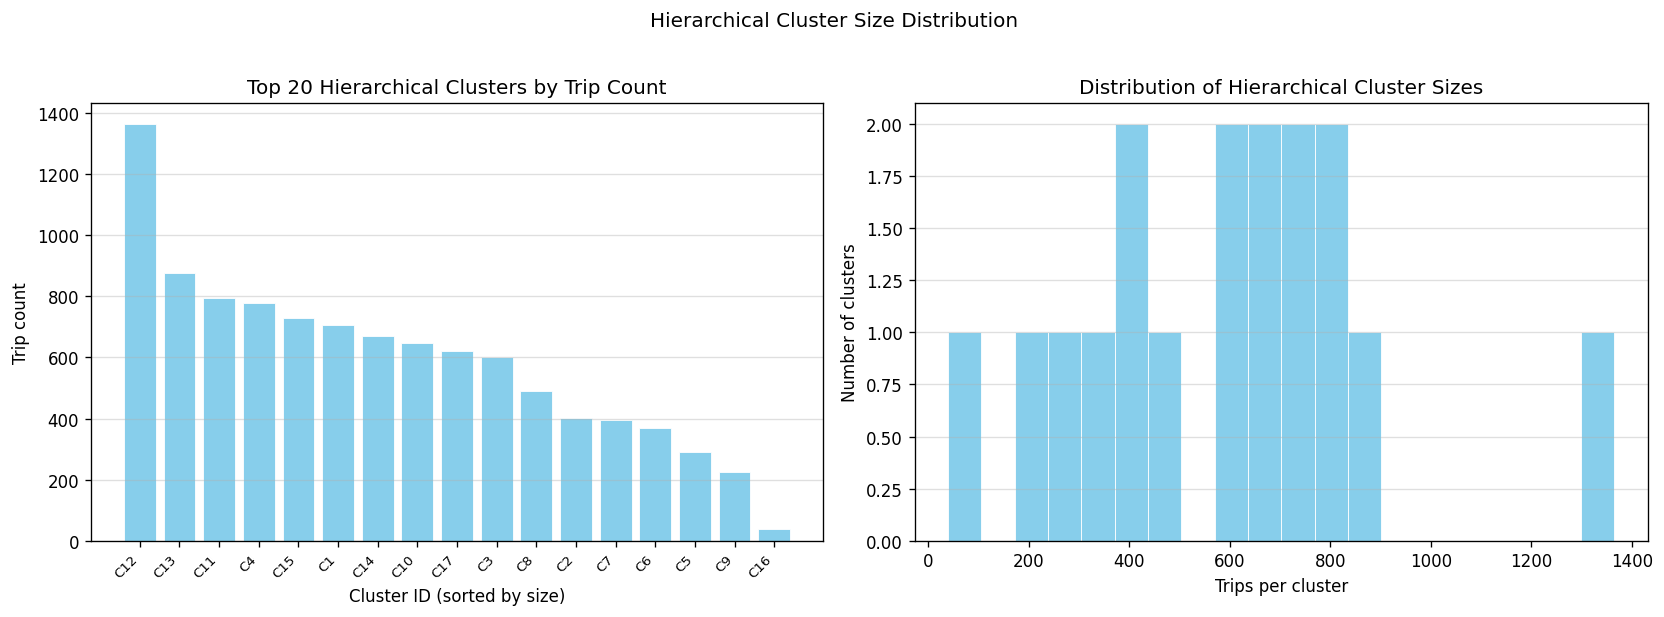

Median cluster size : 621 trips
Largest cluster     : 1365 trips
Smallest cluster    : 40 trips
Std dev of sizes    : 302.0  (lower = more balanced)


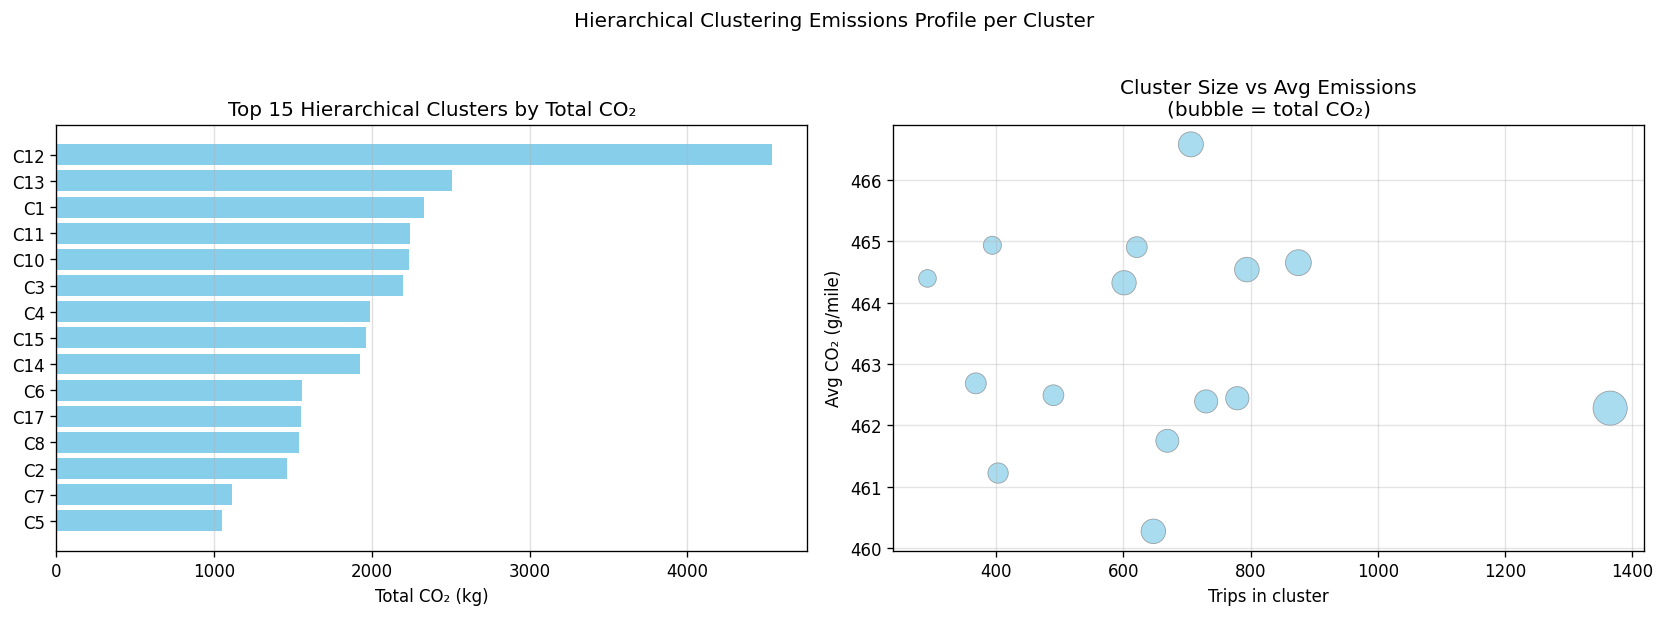


Top 5 highest-emission hierarchical clusters:
 hier_cluster  n_trips  avg_co2_g_mi  total_co2_kg  avg_trip_miles
           12     1365    462.281702   4533.149692        7.191157
           13      875    464.648542   2504.380013        6.124754
            1      706    466.573588   2329.157614        7.050195
           11      794    464.535837   2243.230271        6.095094
           10      647    460.278078   2232.727331        7.477116


In [4]:
# Cluster Size Distributions and Emissions Profile
# -----------------------
# Cluster sizes
# -----------------------
cluster_sizes = (
    df.groupby("hier_cluster").size()
    .reset_index(name="n_trips")
    .sort_values("n_trips", ascending=False)
    .reset_index(drop=True)
)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Top-20 clusters by size
top20 = cluster_sizes.head(20)
axes[0].bar(
    top20.index, 
    top20["n_trips"], 
    color="skyblue", 
    edgecolor="white", 
    linewidth=0.5
)
axes[0].set_xticks(top20.index)
axes[0].set_xticklabels([f"C{int(c)}" for c in top20["hier_cluster"]], rotation=45, ha="right", fontsize=8)
axes[0].set_xlabel("Cluster ID (sorted by size)")
axes[0].set_ylabel("Trip count")
axes[0].set_title("Top 20 Hierarchical Clusters by Trip Count")
axes[0].grid(axis="y", alpha=0.4)

# Histogram of all cluster sizes
axes[1].hist(cluster_sizes["n_trips"], bins=20, color="skyblue", edgecolor="white", linewidth=0.5)
axes[1].set_xlabel("Trips per cluster")
axes[1].set_ylabel("Number of clusters")
axes[1].set_title("Distribution of Hierarchical Cluster Sizes")
axes[1].grid(axis="y", alpha=0.4)

plt.suptitle("Hierarchical Cluster Size Distribution", y=1.02)
plt.tight_layout()
plt.show()

print(f"Median cluster size : {cluster_sizes['n_trips'].median():.0f} trips")
print(f"Largest cluster     : {cluster_sizes['n_trips'].max()} trips")
print(f"Smallest cluster    : {cluster_sizes['n_trips'].min()} trips")
print(f"Std dev of sizes    : {cluster_sizes['n_trips'].std():.1f}  (lower = more balanced)")

# -----------------------
# CO₂ emissions per cluster
# -----------------------
emissions_cluster = (
    df.groupby("hier_cluster")
    .agg(
        n_trips        = ("trip_miles", "count"),
        avg_co2_g_mi   = ("co2_total_g", lambda x: (x / df.loc[x.index, "trip_miles"]).mean()),
        total_co2_kg   = ("co2_total_g", lambda x: x.sum() / 1000),
        avg_trip_miles = ("trip_miles", "mean")
    )
    .reset_index()
    .sort_values("total_co2_kg", ascending=False)
    .head(15)
)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Top 15 clusters by total CO2
axes[0].barh(
    [f"C{int(r['hier_cluster'])}" for _, r in emissions_cluster.iterrows()],
    emissions_cluster["total_co2_kg"], 
    color="skyblue"
)
axes[0].set_xlabel("Total CO₂ (kg)")
axes[0].set_title("Top 15 Hierarchical Clusters by Total CO₂")
axes[0].invert_yaxis()
axes[0].grid(axis="x", alpha=0.4)

# Bubble plot: size vs avg emissions
axes[1].scatter(
    emissions_cluster["n_trips"], 
    emissions_cluster["avg_co2_g_mi"],
    s=emissions_cluster["total_co2_kg"] / emissions_cluster["total_co2_kg"].max() * 400 + 20,
    color="skyblue", alpha=0.7, edgecolors="grey", linewidth=0.5
)
axes[1].set_xlabel("Trips in cluster")
axes[1].set_ylabel("Avg CO₂ (g/mile)")
axes[1].set_title("Cluster Size vs Avg Emissions\n(bubble = total CO₂)")
axes[1].grid(alpha=0.35)

plt.suptitle("Hierarchical Clustering Emissions Profile per Cluster", y=1.02)
plt.tight_layout()
plt.show()

print("\nTop 5 highest-emission hierarchical clusters:")
print(emissions_cluster[["hier_cluster","n_trips","avg_co2_g_mi","total_co2_kg","avg_trip_miles"]].head().to_string(index=False))

In [5]:
# Create clusters on scaled up data: 

# Larger sample
df_large = df_full.sample(n=30000, random_state=42).reset_index(drop=True)

# Preprocessing (same as before)
df_large["pickup_datetime"] = pd.to_datetime(df_large["pickup_datetime"], errors="coerce")
df_large["pickup_lat"] = pd.to_numeric(df_large["pickup_lat"], errors="coerce")
df_large["pickup_lon"] = pd.to_numeric(df_large["pickup_lon"], errors="coerce")
df_large["trip_miles"] = pd.to_numeric(df_large["trip_miles"], errors="coerce")
df_large["co2_total_g"] = pd.to_numeric(df_large["co2_total_g"], errors="coerce")
df_large["trip_time"] = pd.to_numeric(df_large["trip_time"], errors="coerce")

df_large = df_large.dropna(subset=["pickup_lat", "pickup_lon", "pickup_datetime", "PULocationID"])

# Time features
df_large["pickup_hour"] = df_large["pickup_datetime"].dt.hour
df_large["hour_sin"] = np.sin(2 * np.pi * df_large["pickup_hour"] / 24)
df_large["hour_cos"] = np.cos(2 * np.pi * df_large["pickup_hour"] / 24)

# Scaling
X_large = scaler.fit_transform(df_large[features])

# 🔥 Hierarchical clustering
clus_full = hierarchy.linkage(X_large, method="ward")

df_large["hier_cluster"] = fcluster(clus_full, t=BEST_HEIGHT, criterion="distance")

print(len(set(df_large["hier_cluster"])))
print(df_large["hier_cluster"].value_counts().describe())

: 

In [ ]:
# Save full labeled dataset
out_full = "../Data/generated/trips_hierarchical_labeled.csv"
df_large.to_csv(out_full, index=False)
print(f"\nSaved → {out_full}  ({len(df_large):,} rows)")


Saved → ../Data/generated/trips_hierarchical_labeled.csv  (6,131 rows)
